# GFM maximum flood extent with STAC

This notebook will demonstrate how to find data using STAC, load it into a
xarray object and calculate a result.

As an example, we will calculate the maximum flood extent of a certain time range
over an area of interest in Morocco. In February 2026, the area suffered from severe weather and floods.

## Prepare Python environment

In this notebook, we are using Python 3.12.11. First, let's install some necessary Python packages. We also need to install the "ipykernel" packge to enable Jupyter notebooks to run Python code.

In [ ]:
!pip install pyproj xarray shapely pystac_client odc-stac matplotlib rioxarray ipykernel

## First some imports

In [1]:
import pyproj
import rioxarray # noqa
import xarray as xr
from datetime import datetime
from shapely.geometry import box
from pystac_client import Client
from odc import stac as odc_stac
import numpy as np
import pandas as pd
from pathlib import Path 

## Search and load data

We will define our area (AOI) and time range of interest for which we want
to calculate the maximum flood extent for. For defining a bounding box, you can
use [this web tool](http://bboxfinder.com).

All GFM data is registered as a [STAC](https://stacspec.org/en/) collection.
Please find more information about STAC in our [documentation](https://docs.eodc.eu/services/stac.html).

In [2]:
# Define the API URL
api_url = "https://stac.eodc.eu/api/v1"

# Define the STAC collection ID
collection_id = "GFM"

# Define the area of interest (AOI) as a bounding box
# Use portal.gfm.eodc.eu to create an AOI and retrieve the coordinates or another tool like bboxfinder.com
# aoi = box(min_lon, min_lat, max_lon, max_lat)
aoi = box(-6.725286048,34.093280072,-4.792626025,36.073018993)

# Define the time range for the search
time_range = (datetime(2026, 2, 1), datetime(2026, 2, 7))

# Open the STAC catalog using the specified API URL
eodc_catalog = Client.open(api_url)

# Perform a search in the catalog with the specified parameters
search = eodc_catalog.search(
    max_items=1000,             # Maximum number of items to return
    collections=collection_id,  # The collection to search within
    intersects=aoi,             # The area of interest
    datetime=time_range         # The time range for the search
)

# Collect the found items into an item collection
items = search.item_collection()

print(f"On EODC we found {len(items)} items for the given search query")

On EODC we found 39 items for the given search query


We will use the found STAC items to load the data into a xarray.Dataset
object. In order to achieve this, we need to specify the bands which we want to
load. To calculate the maximum flood extent, we are interested in the
"ensemble_flood_extent" layer of each GFM item. Furthermore, we need to specify
the coordinate reference system (CRS) as well as the resolution of the data. All
necessary metadata is saved in each STAC item.
Depending on your Internet connection, running this cell will take some time (around 1min30s). Please be patient and wait until the cell finishes executing. Once the data is loaded, you can proceed with further analysis or visualization.

In [3]:
# Extract the coordinate reference system (CRS) from the first item's properties
crs = pyproj.CRS.from_wkt(items[0].properties["proj:wkt2"])

# Set the resolution of the data
resolution = items[0].properties['gsd']

# Specify the bands to load
bands = ["ensemble_flood_extent"]

# Load the data using odc-stac with the specified parameters
xx = odc_stac.load(
    items, 
    bbox=aoi.bounds,   # Define the bounding box for the area of interest
    crs=crs,   # Set the coordinate reference system
    bands=bands,   # Specify the bands to load
    resolution=resolution,   # Set the resolution of the data
    dtype='uint8',   # Define the data type
    groupby="solar_day",
    # fail_on_error=False,
)

xx

<xarray.Dataset> Size: 718MB
Dimensions:                (y: 12534, x: 11448, time: 5)
Coordinates:
  * y                      (y) float64 100kB 9.249e+06 9.249e+06 ... 8.998e+06
  * x                      (x) float64 92kB 2.944e+06 2.944e+06 ... 3.173e+06
  * time                   (time) datetime64[us] 40B 2026-02-01T18:32:49 ... ...
    spatial_ref            int32 4B 0
Data variables:
    ensemble_flood_extent  (time, y, x) uint8 717MB 255 255 255 ... 255 255 255

## Process locally

First, we filter the data to exclude invalid values and calculate the sum along
the time dimension. The maximum flood extent refers to the largest area covered 
by flooded pixels during the specified time range. Therefore, we convert the
result to a binary mask where each pixel is set to 1 if it was flooded during
the specified time range, and 0 if it was not. Then we start the computation on
the cluster and save the result as a compressed TIFF file. This file can be
visualized in e.g. QGIS.

In [5]:
# Create output directory
output = Path("./output")
output.mkdir(exist_ok=True)
fname = "max_flood_morocco_202602.tif"

# Filter the data to exclude values of 255 (nodata) and 0 (no-flood), then sum
# along the "time" dimension 
data = xx["ensemble_flood_extent"]
filtered_data = data.where((data != 255) & (data != 0))
result = filtered_data.sum(dim="time")

# Convert the result to binary (1 where the sum is greater than 0, otherwise 0)
# and set the data type to uint8 
binary_result = xr.where(result > 0, 1, 0).astype("uint8")

# Save the computed result to a GeoTIFF file with LZW compression
output_path = output.joinpath(fname)
result.rio.to_raster(output_path, compress="LZW")

## Plot with matplotlib

Additionally, we can plot a part of the result with the Python library matplotlib.


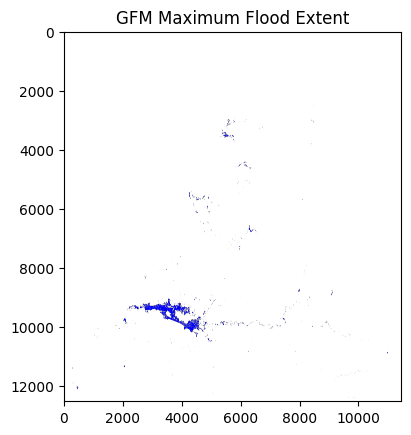

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['none', 'blue'])

plt.figure()
plt.imshow(result, cmap=cmap)
plt.title("GFM Maximum Flood Extent")
plt.show()